In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
# 自动定位项目根目录：notebook 位于 notes/ 下，向上一级即为项目根
cwd = os.getcwd()
if os.path.basename(cwd) == 'notes':
    os.chdir('..')
print('当前工作目录:', os.getcwd())

当前工作目录: d:\github\prediction


In [3]:
#mlp模型 （2）
import torch
from torch import nn
from d2l import torch as d2l

# ============================================================
# 1. 加载数据 (从预处理好的 CSV)
# ============================================================
df_train = pd.read_csv('data/df_train.csv', index_col='datetime', parse_dates=True)
df_test  = pd.read_csv('data/df_test.csv',  index_col='datetime', parse_dates=True)

# 提取 pm_ave 时间序列
x_train = torch.tensor(df_train['pm_ave'].values, dtype=torch.float32)
x_test  = torch.tensor(df_test['pm_ave'].values, dtype=torch.float32)
print(f'训练序列长度: {len(x_train)}  |  测试序列长度: {len(x_test)}')

# ============================================================
# 2. 标准化 (用训练集统计量, pm_ave 量级 0~700 远大于合成数据)
# ============================================================
mean, std = x_train.mean(), x_train.std()
x_train = (x_train - mean) / std
x_test  = (x_test  - mean) / std

# ============================================================
# 3. 构建自回归特征 (用过去 tau 步预测下一步, 与 sequence.ipynb 一致)
# ============================================================
tau = 24  # 回看窗口

# 训练特征: 只用 df_train 的数据
n_train = len(x_train)
features_train = torch.zeros((n_train - tau, tau))
for i in range(tau):
    features_train[:, i] = x_train[i: n_train - tau + i]
labels_train = x_train[tau:].reshape((-1, 1))

# 数据迭代器
batch_size = 16
train_iter = d2l.load_array((features_train, labels_train), batch_size, is_train=True)

# ============================================================
# 4. 定义网络 + 损失 (与 sequence.ipynb 完全一致)
# ============================================================
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.xavier_uniform_(m.weight)

def get_net():
    net = nn.Sequential(nn.Linear(tau, 128), nn.ReLU(), nn.Linear(128, 1))
    net.apply(init_weights)
    return net

loss = nn.MSELoss(reduction='none')

# ============================================================
# 5. 训练 (只用 train 数据, 与 sequence.ipynb 一致)
# ============================================================
def train(net, train_iter, loss, epochs, lr):
    trainer = torch.optim.Adam(net.parameters(), lr)
    for epoch in range(epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.sum().backward()
            trainer.step()
        print(f'epoch {epoch + 1}, '
              f'loss: {d2l.evaluate_loss(net, train_iter, loss):f}')

net = get_net()
train(net, train_iter, loss, 10, 0.01)

# ============================================================
# 6. 测试: 前 24 条公开 (作为起点), 剩余多步预测
#    算法只能看到前 24 条真实值, 之后用自己的预测值作为输入
# ============================================================
n_public = 24  # 前 24 条测试数据是公开的

# 初始化预测数组 (标准化空间), 前 24 条填入真实值
test_preds = torch.zeros(len(x_test))
test_preds[:n_public] = x_test[:n_public]

# 第 24 条起: 多步预测 (用预测值替代未知的真实值作为输入)
for i in range(n_public, len(x_test)):
    test_preds[i] = net(test_preds[i - tau:i].reshape((1, -1)))

# 反标准化回原始量纲 (μg/m³)
preds_all  = (test_preds * std + mean).detach()  # 全部 401 点 (前 24 = 真实)
actual_all = (x_test   * std + mean).detach()     # 全部 401 点真实值

print(f'\n公开起点: 前 {n_public} 条  |  预测区间: 第 {n_public+1} ~ {len(x_test)} 条 (共 {len(x_test)-n_public} 条)')

训练序列长度: 34394  |  测试序列长度: 401


d:\conda_envs\d2l\lib\site-packages\d2l\torch.py:3179: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:836.)
  self.data = [a + float(b) for a, b in zip(self.data, args)]


epoch 1, loss: 0.108518
epoch 2, loss: 0.073718
epoch 3, loss: 0.083830
epoch 4, loss: 0.075933
epoch 5, loss: 0.102184
epoch 6, loss: 0.067591
epoch 7, loss: 0.072287
epoch 8, loss: 0.070683
epoch 9, loss: 0.070835
epoch 10, loss: 0.088669

公开起点: 前 24 条  |  预测区间: 第 25 ~ 401 条 (共 377 条)


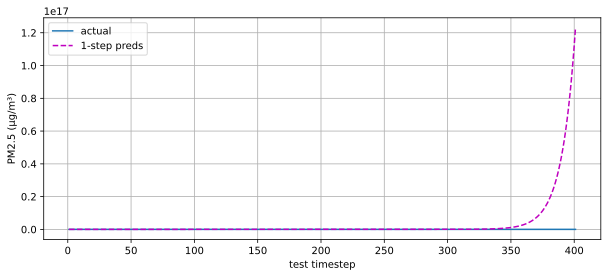

In [4]:
# --- 单步预测图 ---
# 前 24 条: predicted = actual (公开数据)
# 第 25 条起: 多步预测 (算法看不到真实值)
test_time = torch.arange(1, len(x_test) + 1, dtype=torch.float32)
d2l.plot([test_time, test_time],
         [actual_all.numpy(), preds_all.numpy()],
         'test timestep', 'PM2.5 (μg/m³)',
         legend=['actual', '1-step preds'], figsize=(10, 4))

In [5]:
# --- 预测结果表格 + MSE ---
# 只展示预测区间 (第 25 条起, 共 377 条)
df_result = pd.DataFrame({
    'timestamp': df_test.index[n_public:],
    'predicted': preds_all[n_public:].numpy(),
    'actual':    actual_all[n_public:].numpy(),
})
df_result['error'] = df_result['actual'] - df_result['predicted']

# 逐条计算均方误差
err = df_result['error']
mse = (err ** 2).mean()

print(f'预测样本数: {len(df_result)}')
print(f'MSE = {mse:.2f}')
df_result

预测样本数: 377
MSE = 239376384063046964769149843144704.00


,timestamp,predicted,actual,error
0,2015-12-16 07:00:00,7.130804e+01,69.333336,-1.974709e+00
1,2015-12-16 08:00:00,9.276663e+01,71.666664,-2.109997e+01
2,2015-12-16 09:00:00,1.190025e+02,67.333336,-5.166917e+01
3,2015-12-16 10:00:00,1.472891e+02,48.333332,-9.895576e+01
4,2015-12-16 11:00:00,1.769866e+02,29.666664,-1.473200e+02
...,...,...,...,...
372,2015-12-31 19:00:00,8.521485e+16,86.000000,-8.521485e+16
373,2015-12-31 20:00:00,9.340114e+16,87.333336,-9.340114e+16
374,2015-12-31 21:00:00,1.023738e+17,90.000000,-1.023738e+17
375,2015-12-31 22:00:00,1.122085e+17,87.000000,-1.122085e+17
